# Word frequencies

The most basic questions that we can answer using a corpus start with this frequency, or how often something occurs in it, and most of the more advanced questions build from there. This notebook works through some of the the basics using polars:

1. **Absolute frequency** — counting types with `value_counts`.
2. **Relative frequency** — normalizing counts so corpora of different sizes can be compared.
3. **Zipf's law** — the rank/frequency distribution that every corpus turns out to have.
4. **Variation between texts** — per-file rates, their distributions, and how they covary.
5. **Ratios** — normalizing against a choice set instead of against corpus size.

For now we're just using plain polars DataFrames
Everything here uses plain Polars, with no `polars_corpus` functions at all. That is deliberate:
a corpus in this library is just a DataFrame, so the ordinary DataFrame operations are the
foundation the rest of the package sits on, and they are worth being fluent in first. Seaborn and
matplotlib handle the plots.


In [1]:
import polars as pl
import polars.selectors as cs
import seaborn as sns
import matplotlib.pyplot as plt

pl.Config.set_float_precision(3)
pl.Config.set_thousands_separator(",")

polars.config.Config

## The corpus

Our corpus data is represented as a DataFrame with one row per token, in corpus order. Annotations and metadata are stored in extra columns for each row.  

These examples use [AMALGUM](https://gucorpling.org/gum/amalgum.html), a freely redistributable,  automatically annotated corpus of English in seven genres (academic writing, biographies, fiction,
interviews, news, travel guides, and how-to guides). The corpus consists of 3.85 million tokens in 4,683 texts.

The columns:

| column | contents |
| --- | --- |
| `token` | the word form as it appears in the text |
| `pos` | part-of-speech tag (Penn Treebank tagset) |
| `lemma` | dictionary form of the token |
| `sentence_tag` | `B` on the first token of a sentence, `I` elsewhere |
| `file_id` | the document the token belongs to |
| `file_type` | the document's genre |


In [2]:
amalgum = pl.read_parquet("amalgum.parquet")
amalgum.head(10)

token,pos,lemma,sentence_tag,file_id,file_type
str,str,str,str,str,str
"""1.""","""LS""","""1.""","""B""","""AMALGUM_academic_acrylamide""","""academic"""
"""Introduction""","""NN""","""introduction""","""I""","""AMALGUM_academic_acrylamide""","""academic"""
"""Acrylamide""","""NNP""","""Acrylamide""","""B""","""AMALGUM_academic_acrylamide""","""academic"""
""",""",""",""",""",""","""I""","""AMALGUM_academic_acrylamide""","""academic"""
"""a""","""DT""","""a""","""I""","""AMALGUM_academic_acrylamide""","""academic"""
"""thermal""","""JJ""","""thermal""","""I""","""AMALGUM_academic_acrylamide""","""academic"""
"""processing""","""NN""","""processing""","""I""","""AMALGUM_academic_acrylamide""","""academic"""
"""contaminant""","""NN""","""contaminant""","""I""","""AMALGUM_academic_acrylamide""","""academic"""
"""with""","""IN""","""with""","""I""","""AMALGUM_academic_acrylamide""","""academic"""


Tokens and documents are roughly divided evenly across the seven text types:

In [3]:
(
    amalgum.group_by("file_type").agg(
        pl.col("file_id").n_unique().alias("n_files"),
        pl.col("token").len().alias("n_tokens"),
    )
)

file_type,n_files,n_tokens
str,u32,u32
"""news""",808,"590,830"
"""voyage""",600,"660,773"
"""interview""",822,"500,971"
"""whow""",630,"513,967"
"""bio""",598,"498,310"
"""academic""",746,"562,642"
"""fiction""",478,"522,936"


## Token frequency

### Absolute frequency

With one row per token, a frequency list is a count of repeated values. `value_counts` on a
polars Series returns a two-column frame with the distinct values and how often each occurs, and `sort=True` puts the most frequent first.

Each row of the corpus is a **token** (an occurrence of a word), while
each row of the frequency list is a **type** (a distinct form). AMALGUM has 3,850,429 tokens and
143,502 types.


In [4]:
(
    amalgum.group_by("token")
    .agg(pl.len().alias("count"))
    .sort(by="count", descending=True)
    .head(10)
)

token,count
str,u32
""",""","192,424"
"""the""","182,501"
""".""","165,368"
"""of""","100,394"
"""and""","95,116"
"""to""","84,596"
"""a""","67,458"
"""in""","63,088"
"""is""","35,666"


The top of the list is punctuation and grammatical function words. These are the same handful of items
that top the list for almost any English corpus. *The* alone accounts for nearly one token in
twenty.

Two consequences of counting the `token` column as it stands are visible here. Punctuation marks
are tokens. We also didn't tell polars to ignore upper and lower case, so 
sentence-initial *The* is counted separately from *the*. Both are choices, not defaults to
accept silently: the cells below lowercase first, and filtering on the `pos` column would drop
punctuation.


In [5]:
abs_freq = (
    amalgum.with_columns(pl.col("token").str.to_lowercase())
    .filter(pl.col("token").str.contains(r"^[A-Za-z']"))
    .group_by("token")
    .agg(pl.len().alias("count"))
    .sort(by="count", descending=True)
)
abs_freq.head(10)

token,count
str,u32
"""the""","204,055"
"""of""","100,824"
"""and""","97,081"
"""to""","85,730"
"""a""","71,425"
"""in""","69,642"
"""is""","36,100"
"""that""","30,152"
"""for""","29,847"


### Relative frequency

Raw counts are only meaningful within one corpus. To compare a word's frequency here with its
frequency in a corpus of a different size, the count has to be expressed as a rate:

$$\text{rate} = \frac{\text{count}}{\text{corpus size}} \times \text{basis}$$

`normalize=True` asks `value_counts` for the proportion rather than the count, and multiplying by
a basis turns a small decimal into a readable number. The basis is a presentational choice —
per 10,000 words suits common words in short texts, per million suits rarer ones — and it always
has to be reported alongside the figures. This cell scales by 100,000, so a value of 4,997 means
roughly five commas in every hundred words.


In [6]:
rel_freq = abs_freq.select(
    "token", (pl.col("count") / pl.col("count").sum() * 100_000).alias("rate")
)
rel_freq.head(10)

token,rate
str,f64
"""the""","6,264.983"
"""of""","3,095.541"
"""and""","2,980.622"
"""to""","2,632.119"
"""a""","2,192.921"
"""in""","2,138.178"
"""is""","1,108.357"
"""that""",925.739
"""for""",916.375


### Zipf's law

Frequency lists from natural language all have the same shape. If the types are ranked from most
to least frequent, frequency falls off roughly as a power of the rank,

$$f(r) \approx \frac{C}{r^{a}}$$

with $a$ near 1: the second-ranked word occurs about half as often as the first, the tenth about
a tenth as often, and so on.

The query lowercases the tokens first, so *The* and *the* count as one type, and
`with_row_index("rank", offset=1)` numbers the rows of the already-sorted table, giving rank 1 to
the most frequent type. On linear axes the top 500 types drop away almost immediately: a few
dozen very common words, then a tail that looks flat but is not.


<Axes: xlabel='rank', ylabel='count'>

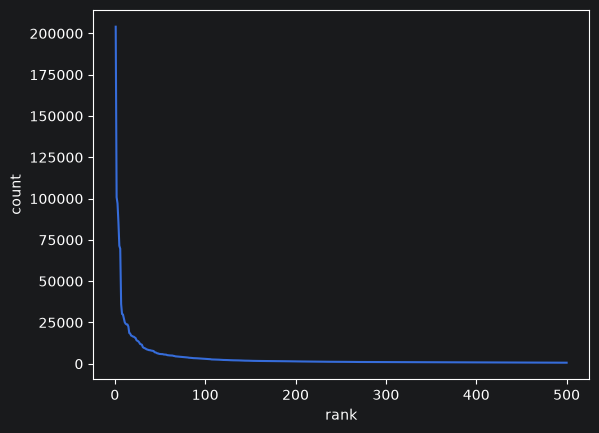

In [7]:
zipf = abs_freq.with_row_index("rank", offset=1)
sns.lineplot(data=zipf.head(500), x="rank", y="count")

The same curve on log–log axes is close to a straight line over several orders of magnitude,
which is what a power law looks like: a constant proportional drop in frequency for a constant
proportional step in rank.

The staircase at the right-hand end is the rank range where many types share the same tiny count.
The final, longest step is the words that occur exactly once — the *hapax legomena*, and there
are 63,314 of them, just over half of the 124,946 distinct lowercased types. Most of a corpus's
vocabulary is barely attested in it, which is why frequency estimates for individual content
words need more care than estimates for *the*.


<Axes: xlabel='rank', ylabel='count'>

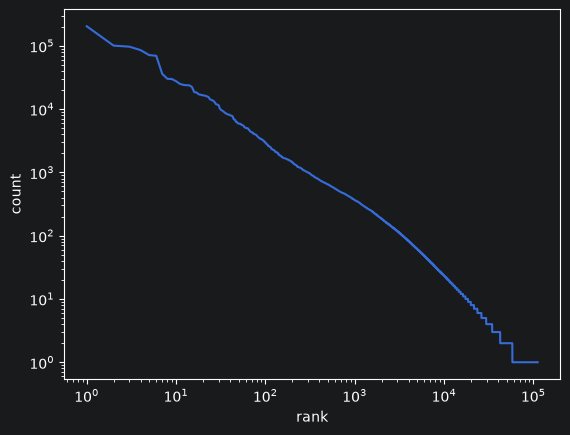

In [8]:
plt.loglog()
sns.lineplot(data=zipf, x="rank", y="count")

## Variation between texts

A corpus-wide rate is an average, and averages hide variation. The same word can be frequent
because every text uses it a little or because a few texts use it constantly. To see which,
compute the rate separately for each file.

The pipeline below restricts the corpus to the 822 interview files, folds case, and then groups
by `file_id`, aggregating four things per file: its length `n`, and the counts of *the*, *I* and
*you*. Comparisons like `pl.col("token") == "the"` produce a boolean column, and `.sum()` on a
boolean counts the `True` values — the standard Polars idiom for "count rows matching a
condition" inside an aggregation.

The `select` then normalizes in one stroke: `cs.numeric().exclude("n")` picks every numeric
column except the file length, divides each by `n`, and scales to a rate per 10,000 words. Using
a selector rather than naming the three words keeps the expression the same length however many
words are tracked.

Brezina (2018), *Statistics in Corpus Linguistics*, p. 26.


In [9]:
the = (
    amalgum.filter(pl.col("file_type") == "interview")
    .with_columns(pl.col("token").str.to_lowercase())
    .group_by("file_id")
    .agg(
        (
            pl.col("token").len().alias("n"),
            (pl.col("token") == "the").sum().alias("the"),
            (pl.col("token") == "i").sum().alias("i"),
            (pl.col("token") == "you").sum().alias("you"),
        )
    )
    .select("file_id", (cs.numeric().exclude("n") / pl.col("n") * 10_000))
)

the.head(10)

file_id,the,i,you
str,f64,f64,f64
"""AMALGUM_interview_bailing""",273.381,143.885,143.885
"""AMALGUM_interview_freeing""",342.742,262.097,201.613
"""AMALGUM_interview_augustus""",207.547,226.415,56.604
"""AMALGUM_interview_treat""",140.845,301.811,261.569
"""AMALGUM_interview_beck""",425.894,153.322,136.286
"""AMALGUM_interview_conestoga""",661.479,58.366,97.276
"""AMALGUM_interview_columbia""",262.238,209.790,104.895
"""AMALGUM_interview_oath""",712.121,121.212,60.606
"""AMALGUM_interview_suzanne""",519.231,346.154,134.615


### How are the per-file rates distributed?

With one number per file, the natural next step is to look at the spread rather than the average.
The two histograms are shaped quite differently:

- *the* is roughly symmetric around 450 per 10,000, but ranges from under 100 to over 1,000. A
  threefold difference between two texts of the same genre is unremarkable.
- *I* is strongly right-skewed, with a mode near zero and a long tail. Some interviews are
  first-person narratives; many are not.

For a distribution like the second one the mean is a poor summary, which is worth remembering
whenever a corpus is reported as a single frequency per million words.


<Axes: xlabel='the', ylabel='Count'>

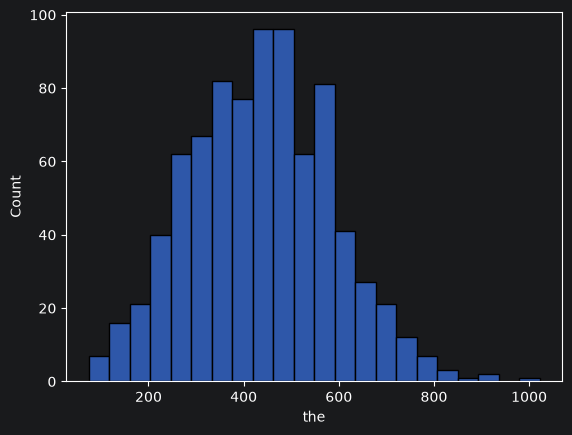

In [10]:
sns.histplot(the, x="the")

<Axes: xlabel='i', ylabel='Count'>

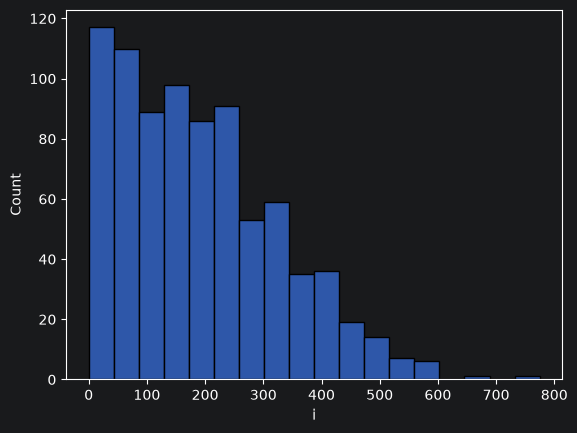

In [11]:
sns.histplot(the, x="i")

### Do the rates move together?

Each point below is one interview file, placed by its rate of *the* and its rate of *I*. The red
line is a LOWESS smoother (`lowess=True`), which follows the data locally instead of assuming the
relationship is a straight line; the transparent markers keep the dense middle of the cloud
readable.

The trend is clearly negative: files that use *the* heavily use *I* sparingly, and vice versa.


(0.0, 800.0)

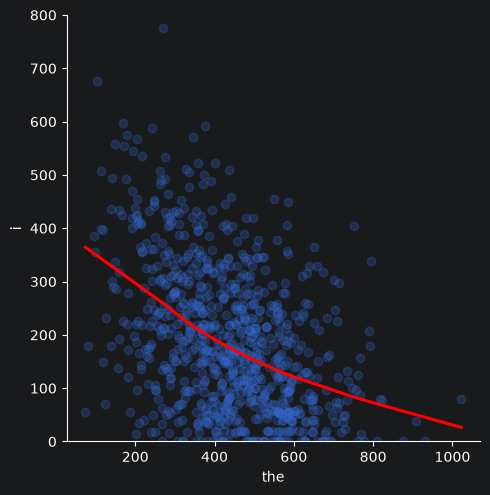

In [12]:
sns.lmplot(
    the,
    x="the",
    y="i",
    scatter_kws={"alpha": 0.25},
    line_kws={"color": "red"},
    lowess=True,
)
plt.ylim(0, 800)

A pair plot shows all three words at once: histograms on the diagonal, a scatter with a smoother
for each pair below it. `corner=True` drops the redundant upper triangle. Seaborn reads the
Polars frame directly for the plots above, but `pairplot` still wants pandas, hence
`.to_pandas()`.

*I* and *you* rise together and both fall as *the* rises. The three rates are not three
independent facts — they are three views of a single dimension of variation, the contrast
between involved, interactive language and informational language (Biber 1988).


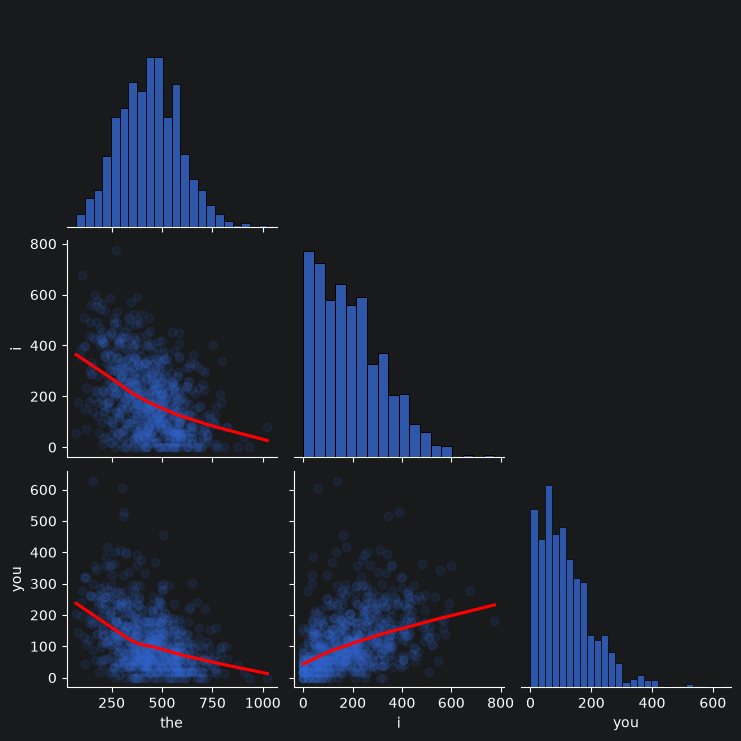

In [13]:
sns.pairplot(
    the.to_pandas(),
    vars=["the", "i", "you"],
    kind="reg",
    corner=True,
    plot_kws={
        "scatter_kws": {"alpha": 0.1},
        "lowess": True,
        "line_kws": {"color": "red"},
    },
)

## Ratios instead of rates

Dividing by the size of the text is not the only way to make counts comparable. When two words
compete for the same slot, the more informative denominator is the choice itself: given that a
writer reached for an intensifier, how often did they pick *really* over *very*?

$$\text{ratio} = \frac{f(\textit{really})}{f(\textit{really}) + f(\textit{very})}$$

This measure needs no normalization — it is unaffected by text length, and unaffected by how
much a text intensifies at all. The pipeline below counts both words per file, forms the ratio,
then averages the ratios within each genre. Two details worth noting:

- `pl.col('file_type').first()` carries the genre label through the `group_by`. The value is
  constant within a file, so any one row will do.
- `.drop_nans()` discards files containing neither word, where the ratio is $0/0$.

Averaging the per-file ratios (rather than pooling all the counts and dividing once) gives every
text an equal vote, so a handful of long files cannot dominate the genre.

The ratios line up as a gradient running from the most edited, most informational genre to the
most speech-like one: *really* takes 3% of the *really*/*very* choices in academic writing but
43% of them in interviews. That is a fact about register, not about how much intensifying each
genre does.



In [14]:
ratio = (
    amalgum.with_columns(pl.col("token").str.to_lowercase())
    .group_by("file_id")
    .agg(
        pl.col("file_type").first(),
        (pl.col("token") == "really").sum().alias("really"),
        (pl.col("token") == "very").sum().alias("very"),
    )
    .with_columns(ratio=pl.col("really") / (pl.col("really") + pl.col("very")))
    .drop_nans()
    .group_by("file_type")
    .agg(pl.col("ratio").mean())
    .sort(by="ratio")
)
ratio

file_type,ratio
str,f64
"""academic""",0.031
"""voyage""",0.120
"""bio""",0.124
"""fiction""",0.170
"""news""",0.206
"""whow""",0.294
"""interview""",0.429
